In [19]:
import pandas as pd
from pathlib import Path

In [27]:
# h = pd.read_csv(
#     Path.cwd().parent / "data" / "existing_infrastructure" / "existing_heating_raw.csv",
#     index_col=0,
# )
h = pd.read_csv(
    Path.cwd().parent / "resources" / "existing_heating_distribution_base_s_50_2025.csv",
    index_col=0,
    header=[0, 1],
)
idx = pd.IndexSlice
h = h.loc[:, idx[['residential rural', 'services rural', 'residential urban decentral', 'services urban decentral'], :]]
h = h.groupby(h.index.str[:2]).sum()
h.columns = h.columns.droplevel(0)

In [32]:
h_clean = h.dropna(how='all')
h_clean = h_clean.T.groupby(h_clean.columns).sum().T

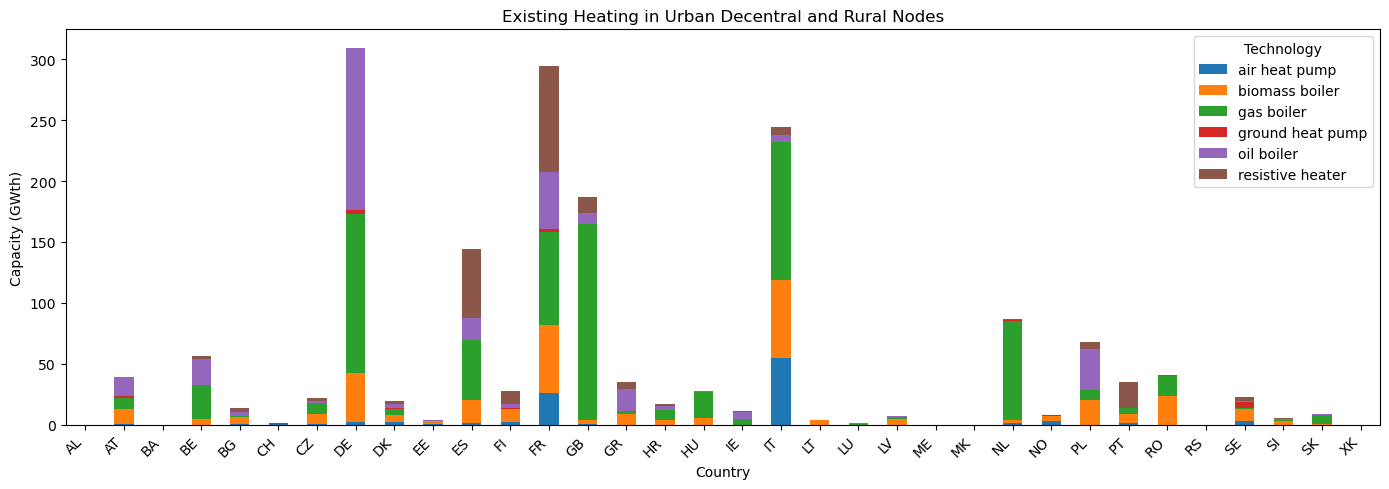

In [36]:
import matplotlib.pyplot as plt

# Remove rows with all NaN values

# Create stacked bar plot
ax = h_clean.mul(1e-3).plot(kind='bar', stacked=True, figsize=(14, 5))

# Customize the plot
ax.set_xlabel('Country')
ax.set_ylabel('Capacity (GWth)')
ax.set_title('Existing Heating in Urban Decentral and Rural Nodes')
ax.legend(title='Technology', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
h

,gas boiler,coal boiler,oil boiler,resistive heater,air heat pump,ground heat pump,biomass stove
Austria,9.32,0.40,15.42,0.00,0.72,1.077,12.158
Belgium,28.39,1.19,19.53,3.14,0.17,0.061,4.304
Bulgaria,0.16,3.68,0.04,3.46,1.01,0.045,5.695
Croatia,8.39,0.03,2.88,1.53,0.00,0.000,3.980
Czech Republic,9.26,1.02,0.10,2.73,0.35,0.263,8.148
Denmark,4.82,0.00,3.67,2.19,1.90,0.381,6.548
Estonia,0.22,0.02,0.12,0.27,0.33,0.100,2.781
Finland,0.00,0.04,3.79,10.30,1.98,0.580,10.830
France,76.85,1.03,46.03,87.24,26.14,1.970,55.423
Germany,131.09,0.44,132.04,0.00,2.38,3.290,39.806
